In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset,ConcatDataset
import numpy as np
import pandas as pd

In [2]:
class CrudeDataset(Dataset):
    mapping = {f"ch{i}": i for i in range(8)}

    def __init__(self, path, seq_len=100):
        self.df = pd.read_csv(path)

        # Ensure correct types early
        self.df["channel"] = self.df["channel"].astype(str)

        # Pre-group for speed + stability
        self.groups = self.df.groupby("batch_id")

        # Keep only valid batch_ids (length >= 2)
        self.batch_ids = [
            bid for bid, g in self.groups
            if len(g) >= 2
        ]

        self.seq_len = seq_len

    def __len__(self):
        return len(self.batch_ids)

    def __getitem__(self, idx):
        batch_id = self.batch_ids[idx]

        # ✅ Safe group access (no copy warning)
        batch_data = self.groups.get_group(batch_id).sort_values("time").copy()

        # =========================
        # Channel mapping (SAFE)
        # =========================
        batch_data["channel"] = batch_data["channel"].map(self.mapping)

        # Fill unmapped channels (important!)
        batch_data["channel"] = batch_data["channel"].fillna(0)

        # =========================
        # TARGET (spoofed)
        # =========================
        target = torch.tensor(
            [float(batch_data.iloc[-1]["spoofed"])],
            dtype=torch.float32
        )

        # =========================
        # DROP UNUSED
        # =========================
        batch_data = batch_data.drop(columns=["spoofed", "time", "batch_id"])

        # Convert to numpy safely
        data = batch_data.to_numpy(dtype=np.float32)

        # =========================
        # SPLIT
        # =========================
        features = data[:-1]           # (T-1, F)
        transformed_target = data[-1]  # (F,)

        # =========================
        # FIX VARIABLE LENGTH (IMPORTANT)
        # =========================
        if len(features) < self.seq_len:
            pad = np.zeros((self.seq_len - len(features), features.shape[1]), dtype=np.float32)
            features = np.vstack([pad, features])
        else:
            features = features[-self.seq_len:]

        # =========================
        # TO TENSOR + CLEAN
        # =========================
        features = torch.from_numpy(features)
        transformed_target = torch.from_numpy(transformed_target)

        # Numerical safety
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        transformed_target = torch.nan_to_num(transformed_target, nan=0.0, posinf=10.0, neginf=-10.0)

        # Clamp (stabilizes training)
        features = torch.clamp(features, -5.0, 5.0)
        transformed_target = torch.clamp(transformed_target, -5.0, 5.0)

        return target, features, transformed_target

In [3]:
train_base="../dataset/train/"
val_base="../dataset/val/"
train_paths=[]
val_paths=[]
for i in range(0,8):
    filename=f"ch{i}.csv"
    train_filepath=train_base+"train_"+filename
    val_filepath=val_base+"val_"+filename
    print(train_filepath)
    print(val_filepath)
    train_paths.append(train_filepath)
    val_paths.append(val_filepath)

../dataset/train/train_ch0.csv
../dataset/val/val_ch0.csv
../dataset/train/train_ch1.csv
../dataset/val/val_ch1.csv
../dataset/train/train_ch2.csv
../dataset/val/val_ch2.csv
../dataset/train/train_ch3.csv
../dataset/val/val_ch3.csv
../dataset/train/train_ch4.csv
../dataset/val/val_ch4.csv
../dataset/train/train_ch5.csv
../dataset/val/val_ch5.csv
../dataset/train/train_ch6.csv
../dataset/val/val_ch6.csv
../dataset/train/train_ch7.csv
../dataset/val/val_ch7.csv


In [4]:
combined_val_dataset = []
combined_train_dataset = []

for train_paths, val_paths in zip(train_paths, val_paths):
    train_dataset=CrudeDataset(train_paths)
    val_dataset=CrudeDataset(val_paths)
    combined_train_dataset.append(train_dataset)
    combined_val_dataset.append(val_dataset)

In [5]:
combined_val_dataset = ConcatDataset(combined_val_dataset)
combined_train_dataset = ConcatDataset(combined_train_dataset)

In [6]:
train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(combined_val_dataset, batch_size=32, shuffle=False)

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1,):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
                
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
                
        # Output layers
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Prediction head
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim)
        )
        
    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape
        # Reshape for transformer
        outputs= {
            'input': x,
            'projected': None,
            'positional_encoded': None,
            'encoder_outputs': [],
            "before_output_projection": None,
            'final_output': None
        }
        x = x.view(batch_size , seq_len, input_dim)
        
        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)
        outputs['projected'] = x.detach().cpu()
        # Add positional encoding
        x = self.pos_encoder(x)
        outputs['positional_encoded'] = x.detach().cpu()
        
        residual = x[:, -1, :]  # (batch, input_dim)

        # Apply transformer
        x = self.transformer(x)  # (batch, seq_len, d_model)
        outputs['encoder_outputs'] = x.detach().cpu()
        
        # Take last timestep
        x = x[:, -1, :]  # (batch, d_model)
        
        # Reshape back
        x = x.view(batch_size, self.d_model)
        
        # Apply layer norm and residual
        x = self.layer_norm1(x+residual)
        x = self.dropout(x)

        outputs["before_output_projection"] = x.detach().cpu()
        
        # Output projection
        output = self.output_projection(x)
        outputs['final_output'] = output.detach().cpu()
        
        return output, outputs

class CNNBlock(nn.Module):
    """CNN block for binary classification after transformer output"""
    def __init__(self, in_channels, hidden_channels=256, dropout=0.1):
        super(CNNBlock, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Second conv block
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Third conv block
            nn.Conv2d(hidden_channels // 2, hidden_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 4),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )
        
        # Global average pooling and classification head
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels // 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)  # Binary classification output
        )
        
    def forward(self, x):
        # x shape: (batch, channels=nhead*num_layers, seq_len, d_model)
        x = self.conv_layers(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        cnn_features = x  # Save features for potential use
        x = self.classifier(x)
        return x, cnn_features


class ImageAnalysis(nn.Module):

    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1, cnn_hidden=256):
        super(ImageAnalysis, self).__init__()

        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers

        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Transformer encoder
        self.encoder_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True
            )
            for _ in range(num_layers)
        ])

        self.to_image = nn.Linear(d_model, nhead * d_model)
        
        # CNN block for binary classification
        # Input channels = nhead * num_layers (concatenated across transformer layers)
        self.cnn_block = CNNBlock(
            in_channels=nhead * num_layers,  # FIXED: multiplied by num_layers
            hidden_channels=cnn_hidden,
            dropout=dropout
        )

    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape

        images=[]

        x = x.view(batch_size, seq_len, input_dim)

        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Apply transformer
        for layer_idx, encoder_layer in enumerate(self.encoder_layers):
            x = encoder_layer(x)

            image = self.to_image(x)  # (batch, seq_len, nhead*d_model)
            image = image.view(batch_size, seq_len, self.nhead, self.d_model)
            image = image.permute(0, 2, 1, 3)  # (batch, nhead, seq_len, d_model)
            images.append(image)

        # Concatenate all transformer layer outputs
        # Shape: (batch, nhead * num_layers, seq_len, d_model)
        result = torch.cat(images, dim=1)
        
        # Apply CNN block for binary classification
        cnn_output, cnn_features = self.cnn_block(result)
        
        final_output = torch.sigmoid(cnn_output)
        
        return final_output, cnn_features


In [8]:
class Head(nn.Module):
    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)  # (B, 1) → RAW LOGITS

In [9]:
from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt

In [10]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [13]:
# Initialize models
timeseries_model = TimeSeriesTransformer()
image_analysis_model = ImageAnalysis(
    input_dim=14,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.3, 
    cnn_hidden=128
)
head_model = Head(dim=188, hidden_dim=64, dropout=0.3)


In [ ]:

# Load checkpoints
checkpoint = torch.load('finetuned_with_head.pth', map_location=device)
timeseries_model.load_state_dict(checkpoint['timeseries_model'])

# Load image model
image_checkpoint = torch.load('best_cnn_model.pth', map_location=device)
image_analysis_model.load_state_dict(image_checkpoint)

# IMPORTANT: Move ALL models to device AFTER loading state_dict
timeseries_model = timeseries_model.to(device)
image_analysis_model = image_analysis_model.to(device)
head_model = head_model.to(device)

# Set to evaluation mode if doing inference
timeseries_model.eval()
image_analysis_model.eval()
head_model.eval()

Head(
  (net): Sequential(
    (0): LayerNorm((188,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=188, out_features=64, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


Starting training...


Epoch 1/15 [Val]: 100%|██████████| 861/861 [00:55<00:00, 15.64it/s, loss=0.586]


  ✓ Saved best model (val_loss: 0.613753)

Epoch 1/15
  Train Loss: 0.832023
  Val Loss:   0.613753
  LR:         0.000050
------------------------------------------------------------


Epoch 2/15 [Val]: 100%|██████████| 861/861 [00:54<00:00, 15.69it/s, loss=0.321]



Epoch 2/15
  Train Loss: 0.923315
  Val Loss:   0.618967
  LR:         0.000050
------------------------------------------------------------


...


Epoch 13/15
  Train Loss: 0.901834
  Val Loss:   0.907981
  LR:         0.000006
------------------------------------------------------------


Epoch 14/15 [Val]: 100%|██████████| 861/861 [00:56<00:00, 15.33it/s, loss=1.49]   



Epoch 14/15
  Train Loss: 0.869150
  Val Loss:   0.943028
  LR:         0.000006
------------------------------------------------------------


Epoch 15/15 [Val]: 100%|██████████| 861/861 [00:55<00:00, 15.38it/s, loss=1.54]   



Epoch 15/15
  Train Loss: 0.884637
  Val Loss:   0.961047
  LR:         0.000006
------------------------------------------------------------

Training completed!


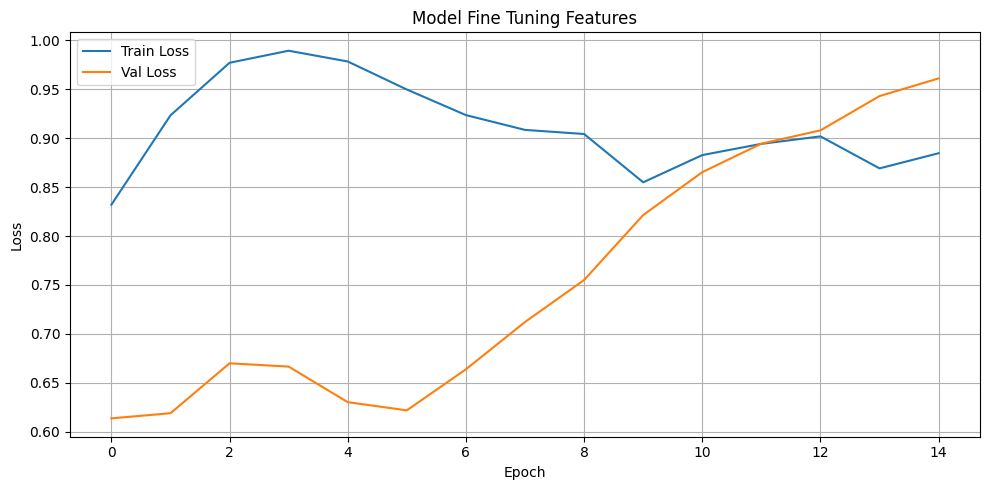

In [52]:
optimizer = torch.optim.Adam([
    {'params': head_model.parameters(), 'lr': 0.00005},
    {'params': timeseries_model.parameters(), 'lr': 0.00005 * 0.1},
    {'params': image_analysis_model.parameters(), 'lr': 0.00005 * 0.1}
])

# Optional: Add learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

criterion = nn.BCEWithLogitsLoss()

# ==================== TRAINING LOOP ====================
num_epochs = 15
best_loss = float('inf')
train_losses, val_losses = [], []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    timeseries_model.train()
    head_model.train()
    image_analysis_model.train()
    
    train_loss = 0
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target in train_bar:
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)

        # Make transformed_target 2D by removing the extra dimension
        if transformed_target.dim() == 3:
            transformed_target = transformed_target.squeeze(1)  # [32, 1, 14] -> [32, 14]

        image_analysis_model_input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)
        
        optimizer.zero_grad()
        
        # Forward pass
        output, outputs = timeseries_model(features)  # [batch, 14]
        temp = outputs["before_output_projection"]    # [batch, 128]
        
        _, cnn_feature = image_analysis_model(image_analysis_model_input)  # [batch, 32]
        
        # Ensure correct dtypes (don't create new tensors!)
        temp = temp.float()
        temp = temp.to(device)
        cnn_feature = cnn_feature.float()
        output = output.float()

        # print(f"Output shape: {output.device}, Temp shape: {temp.device}, CNN feature shape: {cnn_feature.device}")
        # print(f"transformed_target shape: {transformed_target.device}")

        # Concatenate all 2D tensors along feature dimension
        # Remove unsqueeze(1) to keep everything 2D
        fusion = torch.cat([output, transformed_target, temp, cnn_feature], dim=-1)
        fusion = fusion.to(device)
        output = head_model(fusion)
        
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(head_model.parameters()) + 
            list(timeseries_model.parameters()) + 
            list(image_analysis_model.parameters()), 
            max_norm=1.0
        )
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix({'loss': loss.item()})
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    timeseries_model.eval()
    head_model.eval()
    image_analysis_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target in val_bar:
            features = features.to(device)
            target = target.to(device)
            transformed_target = transformed_target.to(device)
            
            # Make transformed_target 2D
            if transformed_target.dim() == 3:
                transformed_target = transformed_target.squeeze(1)

            image_analysis_model_input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)
            
            output, outputs = timeseries_model(features)
            temp = outputs["before_output_projection"]
            temp = temp.to(device)
            _, cnn_feature = image_analysis_model(image_analysis_model_input)
            
            # Concatenate all 2D tensors
            fusion = torch.cat([output, transformed_target, temp.float(), cnn_feature.float()], dim=-1)
            fusion = fusion.to(device)

            output = head_model(fusion)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            val_bar.set_postfix({'loss': loss.item()})
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Learning rate scheduling
    scheduler.step(avg_val)
    
    # Save best model
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save({
            'head_model': head_model.state_dict(),
            'timeseries_model': timeseries_model.state_dict(),
            'image_analysis_model': image_analysis_model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'val_loss': avg_val
        }, 'best_model.pth')
        print(f"  ✓ Saved best model (val_loss: {avg_val:.6f})")
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train:.6f}")
    print(f"  Val Loss:   {avg_val:.6f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")



plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Fine Tuning Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_after_fine_tuning.png')
plt.show()


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_auc_score, precision_score, recall_score, f1_score

In [14]:
checkpoint_final = torch.load('best_model.pth', map_location=device)
timeseries_model.load_state_dict(checkpoint_final['timeseries_model'])
image_analysis_model.load_state_dict(checkpoint_final['image_analysis_model'])
head_model.load_state_dict(checkpoint_final['head_model'])

timeseries_model = timeseries_model.to(device)
image_analysis_model = image_analysis_model.to(device)
head_model = head_model.to(device)

timeseries_model.eval()
image_analysis_model.eval()
head_model.eval()

y_pred_list=[]
y_true_list=[]

for target, features, transformed_target in val_bar:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    
    # Make transformed_target 2D
    if transformed_target.dim() == 3:
        transformed_target = transformed_target.squeeze(1)
    image_analysis_model_input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)
    
    output, outputs = timeseries_model(features)
    temp = outputs["before_output_projection"]
    temp = temp.to(device)
    _, cnn_feature = image_analysis_model(image_analysis_model_input)
    
    # Concatenate all 2D tensors
    fusion = torch.cat([output, transformed_target, temp.float(), cnn_feature.float()], dim=-1)
    fusion = fusion.to(device)
    output = head_model(fusion)
        

    y_pred_list.append(output.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
# If logits → apply sigmoid
y_pred_prob = 1 / (1 + np.exp(-y_pred))  # sigmoid

# Convert to class labels
y_pred_label = (y_pred_prob > 0.5).astype(int)
y_pred_label = y_pred_label.reshape(-1)
y_pred_prob  = y_pred_prob.reshape(-1)
y_true       = y_true.reshape(-1)
print("Accuracy:", accuracy_score(y_true, y_pred_label))
print("Precision:", precision_score(y_true, y_pred_label))
print("Recall:", recall_score(y_true, y_pred_label))
print("F1 Score:", f1_score(y_true, y_pred_label))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_label))

NameError: name 'val_bar' is not defined

In [16]:
checkpoint_final = torch.load('best_model.pth', map_location=device)
timeseries_model = TimeSeriesTransformer()
image_analysis_model = ImageAnalysis(
    input_dim=14,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.3, 
    cnn_hidden=128
)
head_model = Head(dim=188, hidden_dim=64, dropout=0.3)
timeseries_model.load_state_dict(checkpoint_final['timeseries_model'])
image_analysis_model.load_state_dict(checkpoint_final['image_analysis_model'])
head_model.load_state_dict(checkpoint_final['head_model'])

timeseries_model = timeseries_model.to(device)
image_analysis_model = image_analysis_model.to(device)
head_model = head_model.to(device)

timeseries_model.eval()
image_analysis_model.eval()
head_model.eval()

X_list = []
y_list = []

with torch.no_grad():
    for target, features, transformed_target in val_loader:
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)
        
        # Make transformed_target 2D
        if transformed_target.dim() == 3:
            transformed_target = transformed_target.squeeze(1)
        image_analysis_model_input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)
        
        output, outputs = timeseries_model(features)
        temp = outputs["before_output_projection"]
        temp = temp.to(device)
        _, cnn_feature = image_analysis_model(image_analysis_model_input)
        
        # Concatenate all 2D tensors
        fusion = torch.cat([output, transformed_target, temp.float(), cnn_feature.float()], dim=-1)

        X_list.append(fusion.detach().cpu().numpy())
        y_list.append(target.detach().cpu().numpy())

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0).reshape(-1)

print("Feature shape:", X.shape)  # (N, 15)
print("Target shape:", y.shape)

Feature shape: (27532, 188)
Target shape: (27532,)


In [17]:
timeseries_model.eval()

X_list_tr = []
y_list_tr = []


with torch.no_grad():
    for target, features, transformed_target in train_loader:
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)
        
        # Make transformed_target 2D
        if transformed_target.dim() == 3:
            transformed_target = transformed_target.squeeze(1)
        image_analysis_model_input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)
        
        output, outputs = timeseries_model(features)
        temp = outputs["before_output_projection"]
        temp = temp.to(device)
        _, cnn_feature = image_analysis_model(image_analysis_model_input)
        
        # Concatenate all 2D tensors
        fusion = torch.cat([output, transformed_target, temp.float(), cnn_feature.float()], dim=-1)

        X_list_tr.append(fusion.detach().cpu().numpy())
        y_list_tr.append(target.detach().cpu().numpy())

X_tr = np.concatenate(X_list_tr, axis=0)
y_tr = np.concatenate(y_list_tr, axis=0).reshape(-1)

print("Feature shape:", X_tr.shape)  # (N, 15)
print("Target shape:", y_tr.shape)    

Feature shape: (64214, 188)
Target shape: (64214,)


In [19]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier()
model_xgb.fit(X_tr, y_tr)
y_pred_xgb = model_xgb.predict(X)
print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))   
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]) )

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))


XGBoost Accuracy: 0.7282798198459974
XGBoost Precision: 0.7285953298901579
XGBoost Recall: 0.7275897137875926
XGBoost F1 Score: 0.728092174608367
XGBoost ROC-AUC: 0.8438452842342832

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73     13766
         1.0       0.73      0.73      0.73     13766

    accuracy                           0.73     27532
   macro avg       0.73      0.73      0.73     27532
weighted avg       0.73      0.73      0.73     27532



In [20]:
import optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    # Train on given training data
    model.fit(X_tr, y_tr)

    # Predict on FULL X (as you requested)
    y_pred = model.predict(X)

    # Optimize F1 score
    f1 = f1_score(y, y_pred)

    return f1


# =========================
# RUN OPTUNA
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)

print("Best F1 Score:", study.best_value)
print("Best Params:", study.best_params)


# =========================
# TRAIN FINAL MODEL
# =========================
best_params = study.best_params

model_xgb = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_tr, y_tr)

# =========================
# FINAL EVALUATION (your format)
# =========================

y_pred_xgb = model_xgb.predict(X)

print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]))

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))

[I 2026-04-16 20:35:44,483] A new study created in memory with name: no-name-e453c58a-4f88-4d14-8c62-5d8109e91e74
[I 2026-04-16 20:35:59,941] Trial 8 finished with value: 0.717715167888846 and parameters: {'n_estimators': 102, 'max_depth': 6, 'learning_rate': 0.04815260877316142, 'subsample': 0.5459559378674819, 'colsample_bytree': 0.7860772586609468, 'gamma': 3.0970957844203184, 'min_child_weight': 8, 'reg_alpha': 2.393268950695048, 'reg_lambda': 0.350783939136487}. Best is trial 8 with value: 0.717715167888846.
[I 2026-04-16 20:36:03,346] Trial 10 finished with value: 0.724178359366136 and parameters: {'n_estimators': 268, 'max_depth': 3, 'learning_rate': 0.15195601608173678, 'subsample': 0.9979239417490234, 'colsample_bytree': 0.6585843799139082, 'gamma': 1.6645351335477199, 'min_child_weight': 10, 'reg_alpha': 3.6701969715034455, 'reg_lambda': 3.611052495792296}. Best is trial 10 with value: 0.724178359366136.
[I 2026-04-16 20:36:12,852] Trial 6 finished with value: 0.7255942429308

Best F1 Score: 0.7335708490599315
Best Params: {'n_estimators': 393, 'max_depth': 10, 'learning_rate': 0.15793903274537624, 'subsample': 0.6149677911183633, 'colsample_bytree': 0.8231187992381263, 'gamma': 0.640743497546602, 'min_child_weight': 2, 'reg_alpha': 1.507402404601227, 'reg_lambda': 4.528754719729153}
XGBoost Accuracy: 0.7256646810983582
XGBoost Precision: 0.7130220119317013
XGBoost Recall: 0.7553392416097632
XGBoost F1 Score: 0.7335708490599315
XGBoost ROC-AUC: 0.8393795576250089

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72     13766
         1.0       0.71      0.76      0.73     13766

    accuracy                           0.73     27532
   macro avg       0.73      0.73      0.73     27532
weighted avg       0.73      0.73      0.73     27532

